## Setup

In [22]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps, evaluate_mmd_generated

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler, MH_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix,  unif_move, index_ravel_sampler
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [23]:
from src.torch_erg.utils import laplacian_matrix
from src.torch_erg.samplers import MHSampler_Hard

class Measurer(MHSampler_Hard):
    def __init__(self, backend: str):
        super().__init__(backend)

    def observables(self,mtx):
        L = laplacian_matrix(mtx)
        a3 = torch.matmul(torch.matmul(mtx,mtx),mtx)

        edges = torch.sum(mtx)/2
        triangles = torch.trace(a3)/6
        ac = torch.linalg.eigvalsh(L)[1]
        deg = torch.diagonal(L)
        tri_diag = torch.diagonal(a3) / 2

        valid = deg > 1
        local_clust = torch.zeros_like(deg)
        local_clust[valid] = tri_diag[valid] / (deg[valid] * (deg[valid] - 1))
        avg_clustering = torch.mean(local_clust[valid])

        avg_degree = torch.sum(mtx, dim=1).mean()

        return(torch.stack([edges, triangles, ac, avg_degree, avg_clustering]))

measurer = Measurer(backend='cpu')

In [24]:
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_deep= pkl.load(f)

In [25]:
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community = pkl.load(f)

In [26]:
reference = dataset_2community[0][0]
ref_feats = dataset_2community[0][1]

print(f"Reference graph observables: {measurer.observables(reference).numpy()}")

Reference graph observables: [1.0900000e+02 1.2700000e+02 1.0406445e-01 7.2666669e+00 2.7667990e-01]


In [27]:
model_deep(ref_feats, reference)

tensor(188.6816, grad_fn=<SqueezeBackward0>)

---

In [28]:
class HybridSampler(MH_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module):
        super().__init__(backend, model)
        self.model = model

    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        return(torch.stack([edges, triangles]))

#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class NoFeatModel(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [29]:
# Initial parameters
betas = torch.tensor([0., 0.])
weight_deep = 1
weight_erg = 1
niter_params = 500000
niter_sampling = 100000
params_update_every = 3
alpha = 0.001
min_change = 0.001

In [30]:
adj_model = NoFeatModel(model_deep, ref_feats)

sampler = HybridSampler(backend="cuda",model = adj_model)
obs = sampler.observables(reference)
print("constraint observables: ", obs)
reference = reference.to(device)

CUDA backend not available falling back to cpu
constraint observables:  tensor([109., 127.])


In [31]:
params_only_deep = torch.tensor([0., 0.])

observables_deep, graphs_deep = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_only_deep,
                      niter=niter_sampling,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 100000/100000 [02:26<00:00, 680.51it/s]

number of accepted steps is:  77233
number of rejected samples:  22767
Graph sampled:  1581
-----------------------------------
Start obs:  tensor([109., 127.])
Mean obs:  tensor([186.5098, 365.6749])


In [32]:
params, _ = sampler.param_run(graph=reference,
                      observables=obs,
                      params=betas,
                      niter=niter_params,
                      params_update_every=params_update_every,
                      save_every=50,
                      save_params=True,
                      alpha=alpha,
                      min_change=min_change)

100%|██████████| 500000/500000 [16:59<00:00, 490.26it/s]

number of accepted steps is:  259019
number of rejected samples:  240981
number of effective updates is:  86339


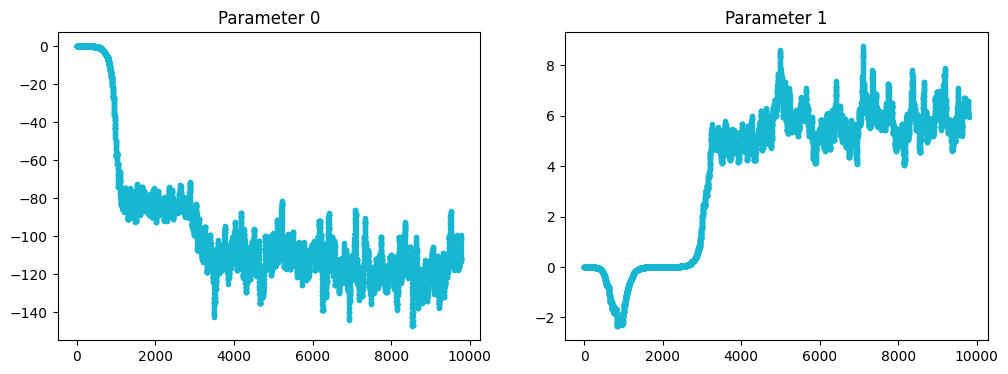

In [33]:
plot_params_iterations(params)

In [34]:
params_for_estimates = torch.stack(params[-1000:]).mean(axis = 0)
params_for_estimates

tensor([-115.7788,    5.9556])

In [35]:
observables_sampled, graphs_sampled = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_for_estimates,
                      niter=100000,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 100000/100000 [02:29<00:00, 668.33it/s]

number of accepted steps is:  54815
number of rejected samples:  45185
Graph sampled:  1592
-----------------------------------
Start obs:  tensor([109., 127.])
Mean obs:  tensor([123.3273, 196.7142])


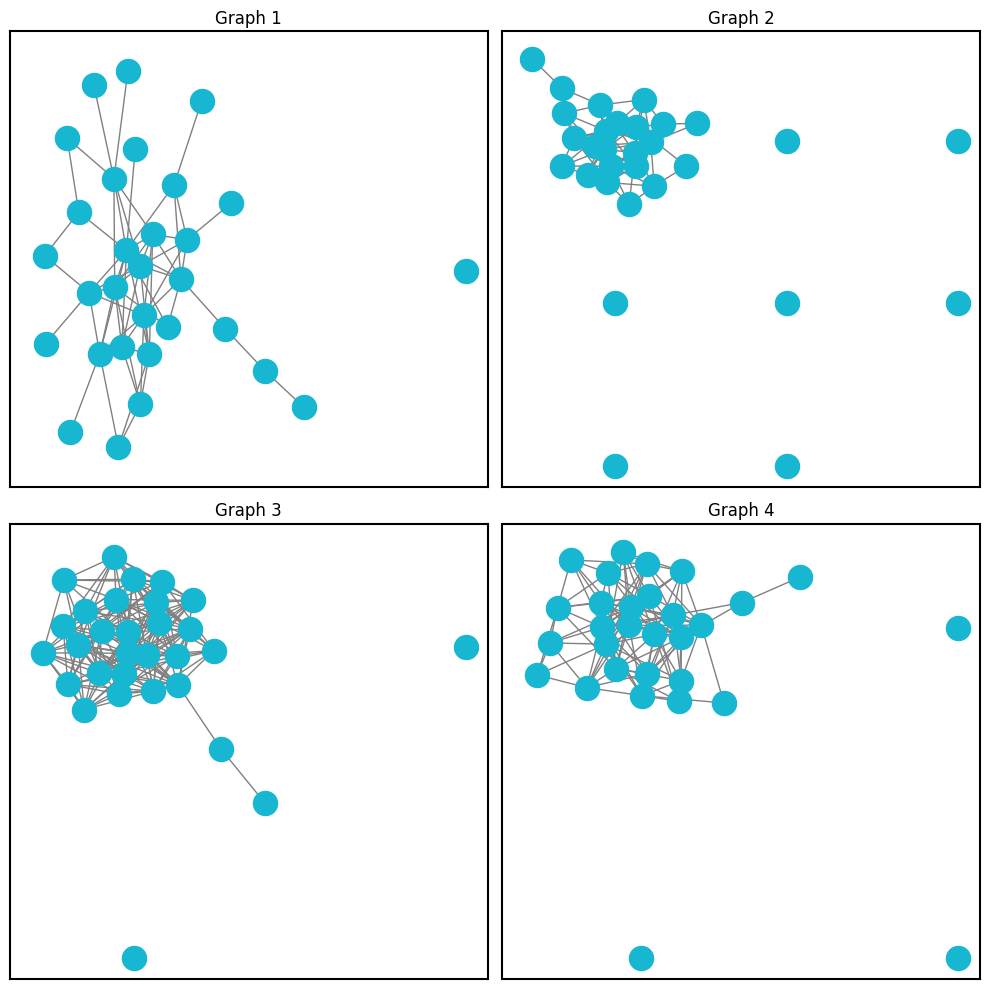

In [40]:
plot_random_graphs(graphs_sampled)

In [41]:
dataset_obs = [measurer.observables(g[0]) for g in dataset_2community]
only_deep_obs = [measurer.observables(g) for g in graphs_deep]
generated_obs = [measurer.observables(g) for g in graphs_sampled]

In [42]:
torch.stack(dataset_obs).mean(dim = 0), torch.stack(dataset_obs).std(dim=0)

(tensor([1.0603e+02, 1.1354e+02, 1.0209e-01, 7.0687e+00, 2.4433e-01]),
 tensor([7.4799e+00, 2.5325e+01, 6.4490e-03, 4.9866e-01, 2.4399e-02]))

In [47]:
def hist_obs_samples(observables_samples: list[torch.Tensor], observable_data: list[torch.Tensor], w = 10, h = 8, scale = 0.6, color = "#11a39c", bins = 30, obs_labels = None):
    num_obs = observables_samples[0].shape[0]
    figsize = (num_obs * w * scale, h * scale)
    
    gen_obs= torch.stack(observables_samples).cpu().numpy()
    data_obs = torch.stack(observable_data).cpu().numpy()

    fig, axes = plt.subplots(1, num_obs, figsize=figsize, squeeze=False)
    
    for p in range(num_obs):
        ax = axes[0, p]

        obs_samples = gen_obs[:, p]
        obs_data    = data_obs[:, p]

        # dataset
        ax.hist(
            obs_data, bins=bins, alpha=0.5, 
            label="Dataset", density=True
        )
        # generati
        ax.hist(
            obs_samples, bins=bins, alpha=0.5, 
            label="Generated", density=True
        )

        if obs_labels is not None:
            ax.set_title(f'{obs_labels[p]}')
        else:
            ax.set_title(f'Observable {p}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

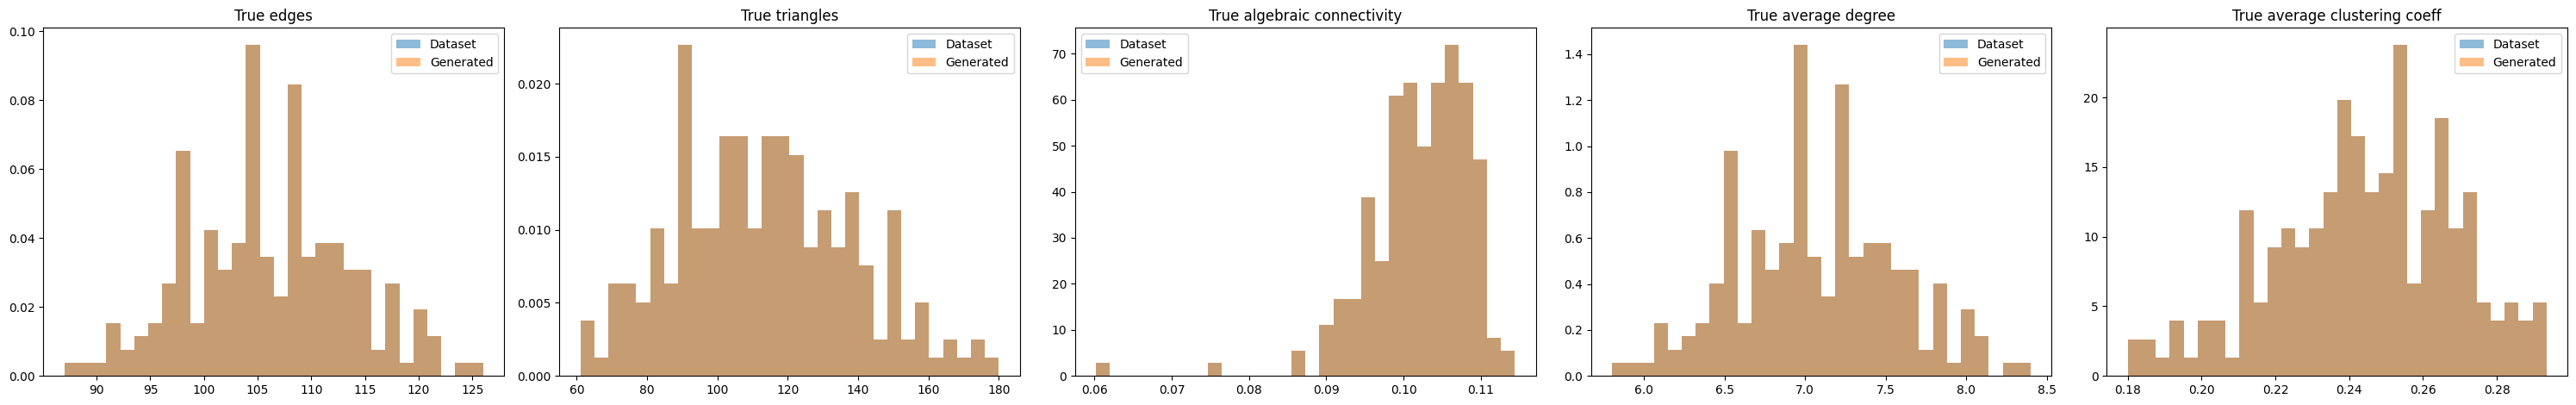

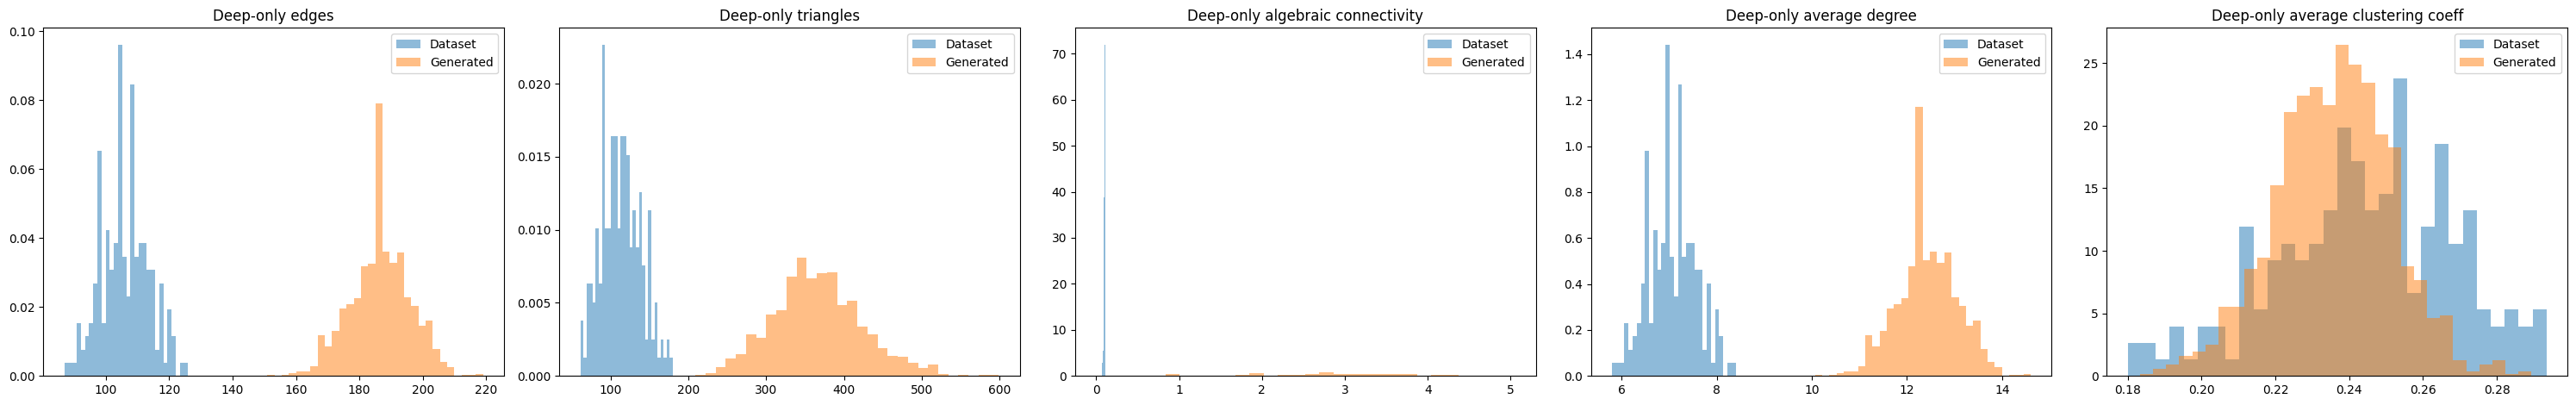

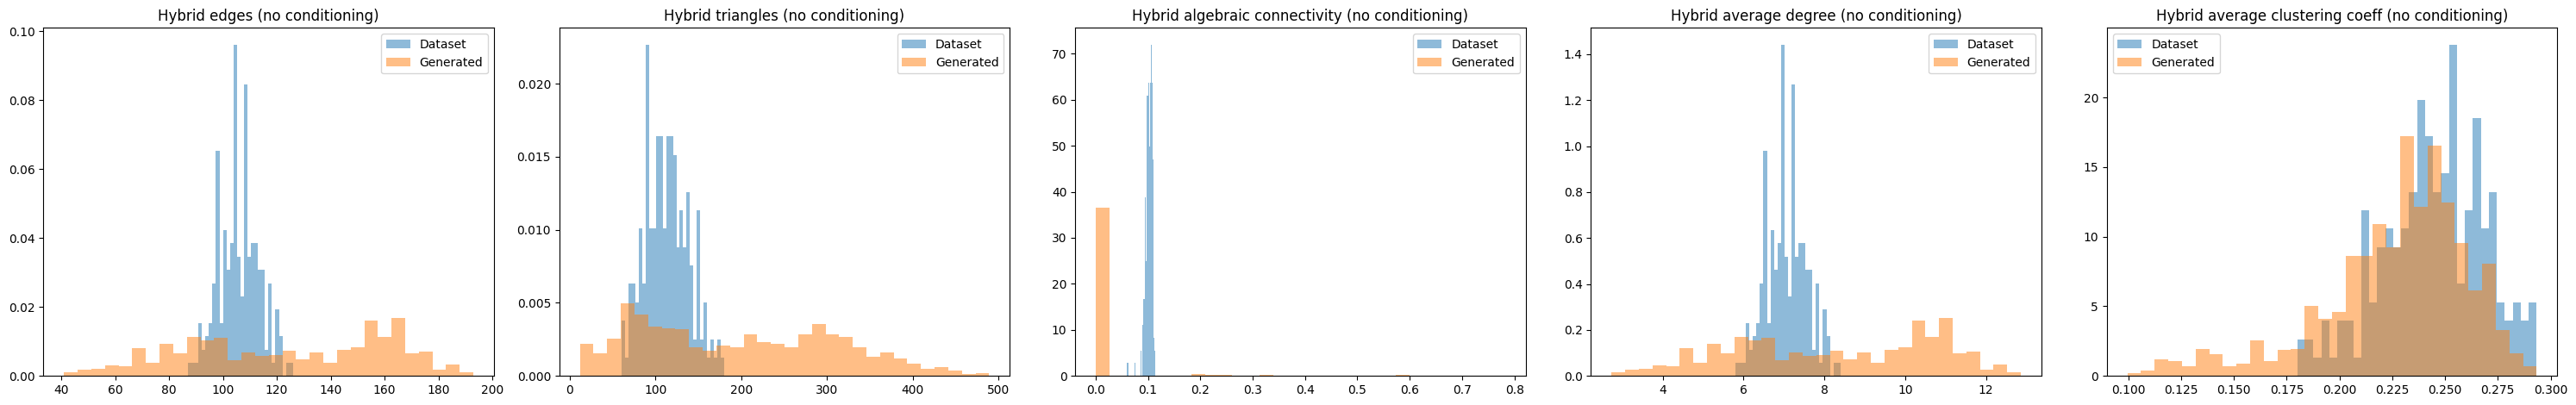

In [48]:
hist_obs_samples(dataset_obs,dataset_obs, obs_labels=['True edges', 'True triangles', 'True algebraic connectivity', 'True average degree', 'True average clustering coeff'])
hist_obs_samples(only_deep_obs, dataset_obs, obs_labels=['Deep-only edges', 'Deep-only triangles', 'Deep-only algebraic connectivity', 'Deep-only average degree', 'Deep-only average clustering coeff'])
hist_obs_samples(generated_obs, dataset_obs, obs_labels=['Hybrid edges (no conditioning)', 'Hybrid triangles (no conditioning)', 'Hybrid algebraic connectivity (no conditioning)', 'Hybrid average degree (no conditioning)', 'Hybrid average clustering coeff (no conditioning)'])
